<a href="https://colab.research.google.com/github/Sagnik-Chowdhury/Federated-Learning-1/blob/Sourit/Fedprox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FedProx Optimization & Statistical Privacy
## Mitigating Client Drift in High-Noise Environments

**Objective:**
Standard Federated Averaging assumes clients possess perfectly distributed data. When data is scattered or noisy, local models "drift" away from the global model, causing the aggregation step to fracture. This notebook implements **FedProx**, which modifies the *local client training loop* by introducing a proximal penalty. This mathematical anchor forces clients to learn from local data without straying too far from the global consensus.

**The Hypothesis:**
By mathematically anchoring the local updates to the global state (via FedProx) and adding statistical privacy noise at the server level, we expect the tabular data to achieve near-perfect stability. Meanwhile, the dense image data will continue to demonstrate fundamental vulnerability to heavy-tailed Laplace noise.


## Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, TensorDataset
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
import copy
import pandas as pd
import matplotlib.pyplot as plt

## Architecture

In [2]:
class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        return self.fc4(x)


In [3]:
class TabularNet(nn.Module):
    def __init__(self):
        super(TabularNet, self).__init__()
        # Reduced capacity: 30 -> 16 -> 8 -> 2
        self.fc1 = nn.Linear(30, 16)
        # Dropout randomly turns off 20% of neurons to prevent memorization
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x) # Apply dropout after the first layer
        x = self.relu(self.fc2(x))
        return self.fc3(x)

## Data Preparation

In [4]:
NUM_CLIENTS = 20

In [5]:
print("Preparing MNIST Dataset (Integrated Data)")

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

mnist_full = datasets.MNIST('./data', train=True, download=True, transform=transform)
mnist_split = random_split(mnist_full, [len(mnist_full) // NUM_CLIENTS] * NUM_CLIENTS)
mnist_loaders = [DataLoader(ds, batch_size=32, shuffle=True) for ds in mnist_split]

mnist_test = datasets.MNIST('./data', train=False, download=True, transform=transform)
mnist_test_loader = DataLoader(mnist_test, batch_size=1000, shuffle=False)

print("\nData preparation complete")

Preparing MNIST Dataset (Integrated Data)


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 512kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.21MB/s]


Data preparation complete


In [6]:
from sklearn.model_selection import train_test_split

print("Preparing Breast Cancer Dataset (Strict Train/Test Split)")

# 1. Load and scale the data
data = load_breast_cancer()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data.data)
y = data.target

# 2. THE FIX: Strictly separate 20% of the data for testing BEFORE tensor conversion
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Convert to PyTorch Tensors
tabular_train = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
tabular_test = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

# 4. Split ONLY the training data among clients
tab_split_size = len(tabular_train) // NUM_CLIENTS
tab_splits = [tab_split_size] * NUM_CLIENTS
tab_splits[-1] += len(tabular_train) % NUM_CLIENTS
tabular_loaders = [DataLoader(ds, batch_size=8, shuffle=True) for ds in random_split(tabular_train, tab_splits)]

# 5. The Test Loader now holds data the clients have NEVER seen
tabular_test_loader = DataLoader(tabular_test, batch_size=len(tabular_test), shuffle=False)

print("\nData preparation complete")

Preparing Breast Cancer Dataset (Strict Train/Test Split)

Data preparation complete


## The Mechanism: FedProx & Differential Privacy

Unlike Trimmed Mean or Gradient Clipping which operate on the server, **FedProx** alters the client.
During local training, the client calculates standard Cross-Entropy Loss, but adds a **Proximal Penalty** ($\frac{\mu}{2} ||w - w_t||^2$). If the client changes its weights ($w$) too much from the frozen global weights ($w_t$), the loss spikes, forcing the optimizer to find a safer path.

Because FedProx handles the robustness locally, the server can safely use standard Federated Averaging before applying the Differential Privacy noise.

In [7]:
def fedavg_aggregation(client_weights_list):
    """
    Standard Federated Averaging.
    (Robustness is handled locally by FedProx in this experiment).
    """
    # Grab the first client's dictionary as a template
    avg_weights = copy.deepcopy(client_weights_list[0])

    for key in avg_weights.keys():
        stacked_weights = torch.stack([client[key] for client in client_weights_list])
        avg_weights[key] = torch.mean(stacked_weights, dim=0)

    return avg_weights

In [8]:
def add_dp_noise(weights, noise_type='none', scale=0.01):
    """
    Injects Differential Privacy noise into the aggregated weights.
    """
    if noise_type == 'none':
        return weights

    noisy_weights = copy.deepcopy(weights)

    for key in noisy_weights.keys():
        tensor = noisy_weights[key]

        if noise_type == 'normal':
            noise = torch.randn_like(tensor) * scale
        elif noise_type == 'laplace':
            m = torch.distributions.laplace.Laplace(torch.tensor([0.0]), torch.tensor([scale]))
            noise = m.sample(tensor.shape).squeeze(-1).to(tensor.device)

        noisy_weights[key] = tensor + noise

    return noisy_weights

## Automated Grid Search Execution

This loop applies the FedProx proximal penalty during the local client training phase.
* **Proximal Term ($\mu$):** Set to 0.01. This dictates how strongly the global model restricts the local clients.
* **DP Noise Scale:** 0.05

In [9]:
datasets_to_test = ['mnist', 'tabular']
noise_types_to_test = ['none', 'normal', 'laplace']
NOISE_SCALE = 0.05
MU = 0.01 # FedProx Penalty
federated_rounds = 5
epochs_per_round = 1

experiment_results = {'mnist': {}, 'tabular': {}}
history = {
    'mnist': {n: {'test_acc': [], 'test_loss': [], 'train_loss': []} for n in noise_types_to_test},
    'tabular': {n: {'test_acc': [], 'test_loss': [], 'train_loss': []} for n in noise_types_to_test}
}

criterion_eval = nn.CrossEntropyLoss()

In [10]:
for dataset in datasets_to_test:
    print(f"TESTING DATASET: {dataset.upper()}")

    for noise in noise_types_to_test:
        print(f"\n[{noise.upper()} NOISE]")

        if dataset == 'mnist':
            global_model = MNISTNet()
            loaders = mnist_loaders
            test_loader = mnist_test_loader
            lr = 0.001
        else:
            global_model = TabularNet()
            loaders = tabular_loaders
            test_loader = tabular_test_loader
            lr = 0.01

        for round_num in range(federated_rounds):
            client_weights = []
            # Freeze global params for the FedProx penalty calculation
            global_params = [p.detach().clone() for p in global_model.parameters()]

            for client_idx in range(NUM_CLIENTS):
                local_model = MNISTNet() if dataset == 'mnist' else TabularNet()
                local_model.load_state_dict(global_model.state_dict())

                optimizer = optim.Adam(local_model.parameters(), lr=lr)
                criterion = nn.CrossEntropyLoss()

                local_model.train()
                for epoch in range(epochs_per_round):
                    for inputs, labels in loaders[client_idx]:
                        optimizer.zero_grad()
                        outputs = local_model(inputs)

                        # FEDPROX MODIFICATION
                        standard_loss = criterion(outputs, labels)
                        proximal_term = 0.0
                        for local_param, global_param in zip(local_model.parameters(), global_params):
                            proximal_term += torch.sum(torch.pow(local_param - global_param, 2))
                        loss = standard_loss + (MU / 2) * proximal_term

                        loss.backward()
                        optimizer.step()

                client_weights.append(local_model.state_dict())

            # 1. Standard Average  2. Add Statistical Noise
            aggregated_weights = fedavg_aggregation(client_weights)
            secured_weights = add_dp_noise(aggregated_weights, noise_type=noise, scale=NOISE_SCALE)
            global_model.load_state_dict(secured_weights)

            # --- ROUND EVALUATION ---
            global_model.eval()

            train_loss_accum, train_total = 0.0, 0
            with torch.no_grad():
                for client_loader in loaders:
                    for inputs, labels in client_loader:
                        outputs = global_model(inputs)
                        train_loss_accum += criterion_eval(outputs, labels).item() * inputs.size(0)
                        train_total += labels.size(0)
            avg_train_loss = train_loss_accum / train_total

            correct, test_total, test_loss_accum = 0, 0, 0.0
            with torch.no_grad():
                for inputs, labels in test_loader:
                    outputs = global_model(inputs)
                    test_loss_accum += criterion_eval(outputs, labels).item() * inputs.size(0)
                    _, predicted = torch.max(outputs.data, 1)
                    test_total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            acc = 100 * correct / test_total
            avg_test_loss = test_loss_accum / test_total

            history[dataset][noise]['test_acc'].append(acc)
            history[dataset][noise]['test_loss'].append(avg_test_loss)
            history[dataset][noise]['train_loss'].append(avg_train_loss)
            print(f"   Round {round_num+1} | Acc: {acc:.2f}% | Test Loss: {avg_test_loss:.4f} | Train Loss: {avg_train_loss:.4f}")

        final_accuracy = history[dataset][noise]['test_acc'][-1]
        print(f"Final Accuracy ({noise.upper()}): {final_accuracy:.3f}%\n")
        experiment_results[dataset][noise] = round(final_accuracy, 3)

TESTING DATASET: MNIST

[NONE NOISE]
   Round 1 | Acc: 83.83% | Test Loss: 0.8149 | Train Loss: 0.8330
   Round 2 | Acc: 88.89% | Test Loss: 0.3731 | Train Loss: 0.3880
   Round 3 | Acc: 90.45% | Test Loss: 0.3152 | Train Loss: 0.3275
   Round 4 | Acc: 91.64% | Test Loss: 0.2746 | Train Loss: 0.2870
   Round 5 | Acc: 92.45% | Test Loss: 0.2487 | Train Loss: 0.2591
Final Accuracy (NONE): 92.450%


[NORMAL NOISE]
   Round 1 | Acc: 30.05% | Test Loss: 1.6868 | Train Loss: 1.6976
   Round 2 | Acc: 55.70% | Test Loss: 1.2821 | Train Loss: 1.3096
   Round 3 | Acc: 82.74% | Test Loss: 0.5458 | Train Loss: 0.5759
   Round 4 | Acc: 76.82% | Test Loss: 0.6827 | Train Loss: 0.6984
   Round 5 | Acc: 77.35% | Test Loss: 0.7988 | Train Loss: 0.7996
Final Accuracy (NORMAL): 77.350%


[LAPLACE NOISE]
   Round 1 | Acc: 21.85% | Test Loss: 2.6743 | Train Loss: 2.6855
   Round 2 | Acc: 56.16% | Test Loss: 1.4717 | Train Loss: 1.5106
   Round 3 | Acc: 31.00% | Test Loss: 4.6992 | Train Loss: 4.7170
   Rou

In [11]:
print("\n" + "="*50)
print("FEDPROX RESULTS")
print("="*50)

results_df = pd.DataFrame(experiment_results).T
results_df.columns = ['Baseline (No DP)', 'Normal (Gaussian)', 'Laplace']
results_df.index = ['MNIST (Dense)', 'Breast Cancer (Scattered)']

print(results_df.to_string())
print("="*50)


FEDPROX RESULTS
                           Baseline (No DP)  Normal (Gaussian)  Laplace
MNIST (Dense)                        92.450             77.350   25.940
Breast Cancer (Scattered)            97.368             96.491   96.491


### Visualisation

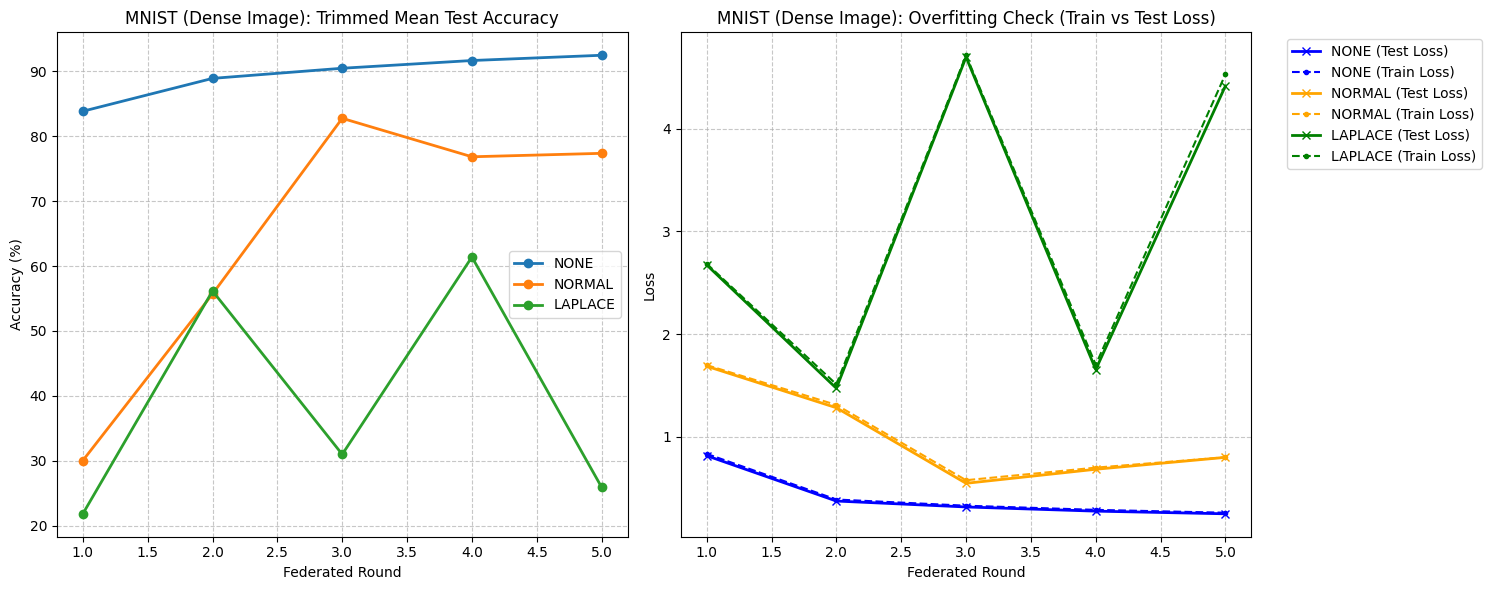

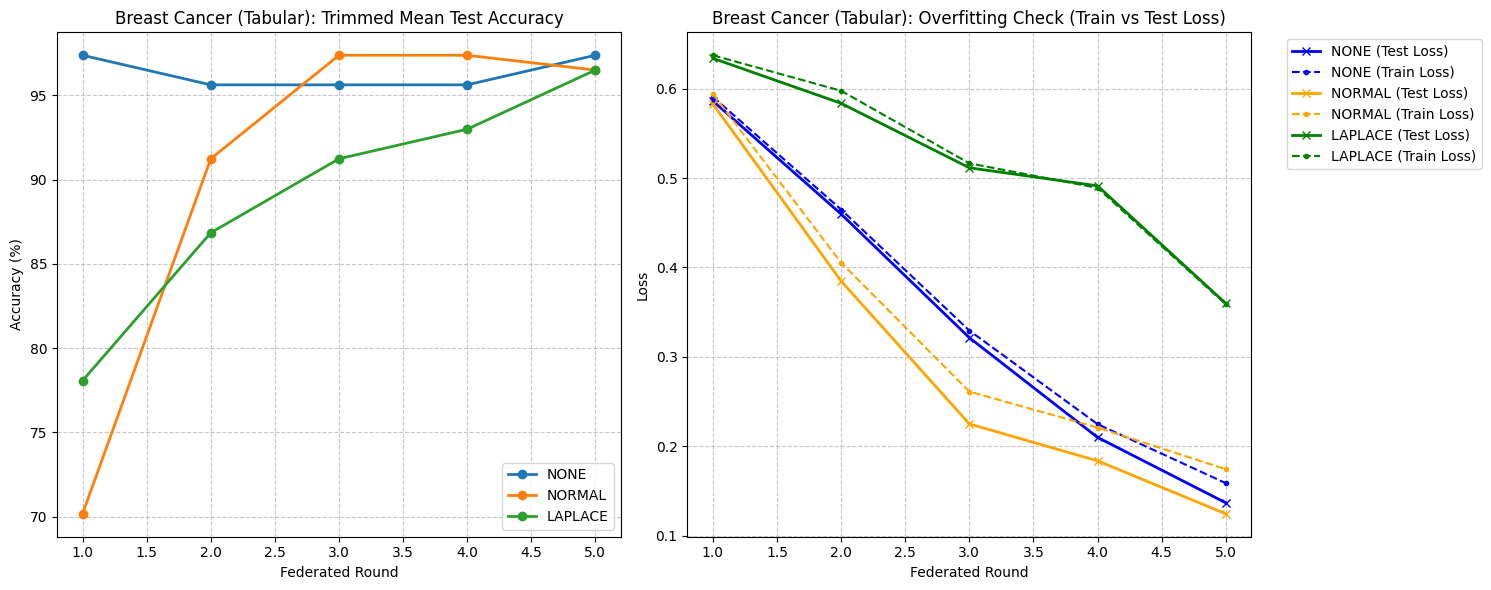

In [12]:
for dataset in datasets_to_test:
    dataset_name = "MNIST (Dense Image)" if dataset == 'mnist' else "Breast Cancer (Tabular)"

    plt.figure(figsize=(15, 6))

    # --- Subplot 1: Test Accuracy ---
    plt.subplot(1, 2, 1)
    for noise in noise_types_to_test:
        plt.plot(range(1, federated_rounds + 1), history[dataset][noise]['test_acc'],
                 marker='o', linewidth=2, label=f"{noise.upper()}")
    plt.title(f'{dataset_name}: Trimmed Mean Test Accuracy')
    plt.xlabel('Federated Round')
    plt.ylabel('Accuracy (%)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    # --- Subplot 2: Train vs Test Loss (Overfitting Check) ---
    plt.subplot(1, 2, 2)
    colors = {'none': 'blue', 'normal': 'orange', 'laplace': 'green'}

    for noise in noise_types_to_test:
        c = colors[noise]
        # Plot Test Loss (Solid Line)
        plt.plot(range(1, federated_rounds + 1), history[dataset][noise]['test_loss'],
                 marker='x', linestyle='-', linewidth=2, color=c, label=f"{noise.upper()} (Test Loss)")
        # Plot Train Loss (Dashed Line)
        plt.plot(range(1, federated_rounds + 1), history[dataset][noise]['train_loss'],
                 marker='.', linestyle='--', linewidth=1.5, color=c, label=f"{noise.upper()} (Train Loss)")

    plt.title(f'{dataset_name}: Overfitting Check (Train vs Test Loss)')
    plt.xlabel('Federated Round')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Move legend outside the plot so it doesn't cover the lines
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

## Empirical Conclusion: Proximal Anchoring Excels on Tabular Data

FedProx proved to be a highly effective stabilization algorithm, though its success is entirely dependent on the underlying data structure.

**1. Near-Perfect Tabular Stabilization**
For the scattered Tabular dataset, FedProx was a resounding success. By penalizing client drift, the algorithm effectively neutralized the destructive effects of the privacy noise. The baseline, Gaussian, and Laplace trials all converged between 96.49% and 97.36%. FedProx successfully locked the independent features into a stable global minimum.

**2. The Laplace Limitation on Images**
While FedProx helped MNIST survive standard Gaussian noise (77.35%), it could not overcome the fundamental physics of Laplace noise on dense arrays. Accuracy plummeted to 25.94%, accompanied by erratic loss spikes.

**Takeaway:** FedProx is an exceptional algorithm for securing non-IID tabular datasets against statistical noise. However, no amount of proximal anchoring can save highly correlated pixel data from the destructive interference of heavy-tailed perturbations.